In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [ ]:
df = pd.read_csv("winequality-red.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.isna().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'quality' in numerical_cols:
    numerical_cols.remove('quality')

print("Numerical columns to analyze:", numerical_cols)

Numerical columns to analyze: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


count    1599.000000
mean        8.319637
std         1.741096
min         4.600000
25%         7.100000
50%         7.900000
75%         9.200000
max        15.900000
Name: fixed acidity, dtype: float64


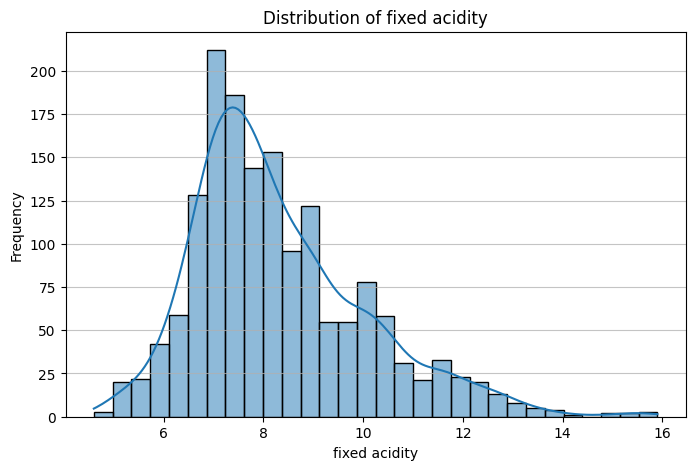

count    1599.000000
mean        0.527821
std         0.179060
min         0.120000
25%         0.390000
50%         0.520000
75%         0.640000
max         1.580000
Name: volatile acidity, dtype: float64


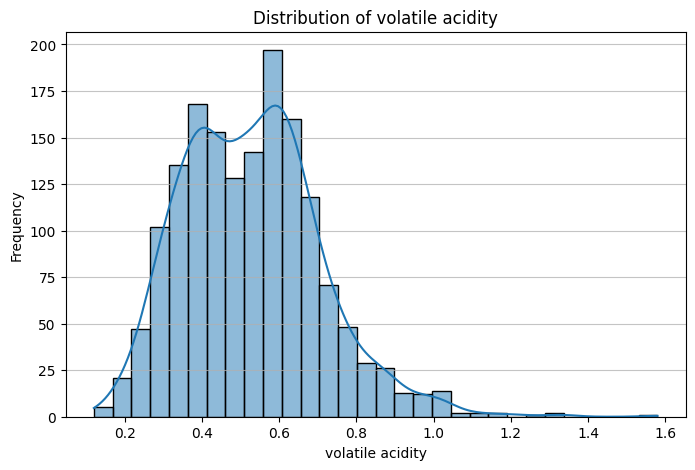

count    1599.000000
mean        0.270976
std         0.194801
min         0.000000
25%         0.090000
50%         0.260000
75%         0.420000
max         1.000000
Name: citric acid, dtype: float64


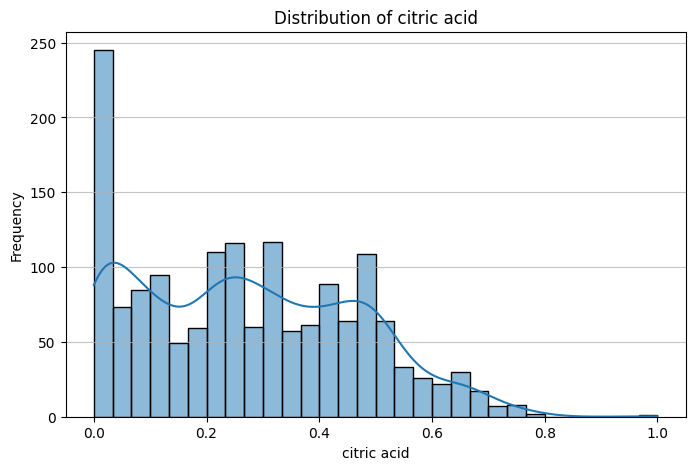

count    1599.000000
mean        2.538806
std         1.409928
min         0.900000
25%         1.900000
50%         2.200000
75%         2.600000
max        15.500000
Name: residual sugar, dtype: float64


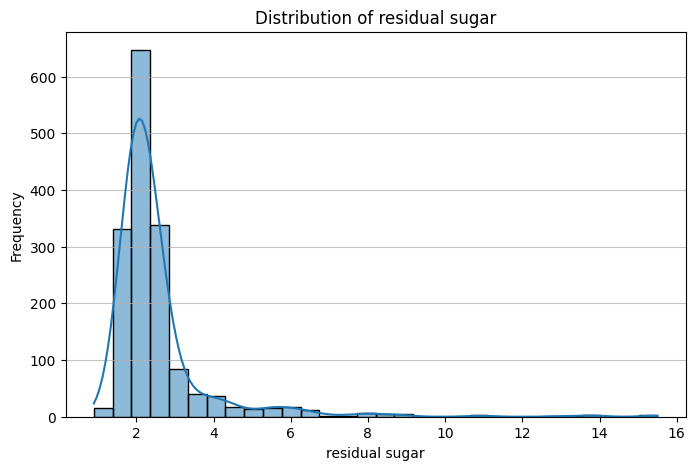

count    1599.000000
mean        0.087467
std         0.047065
min         0.012000
25%         0.070000
50%         0.079000
75%         0.090000
max         0.611000
Name: chlorides, dtype: float64


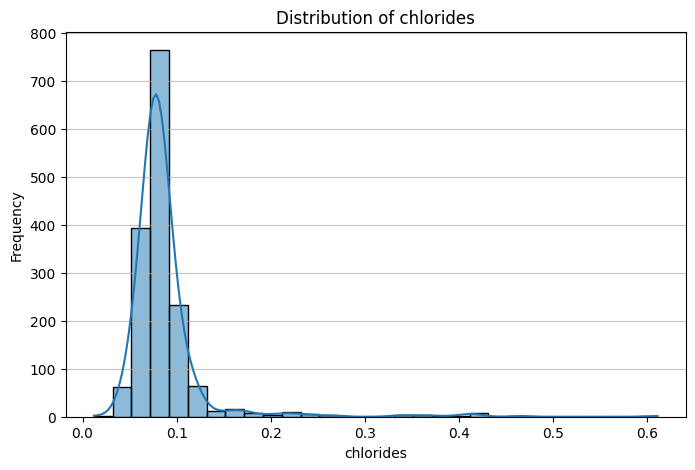

count    1599.000000
mean       15.874922
std        10.460157
min         1.000000
25%         7.000000
50%        14.000000
75%        21.000000
max        72.000000
Name: free sulfur dioxide, dtype: float64


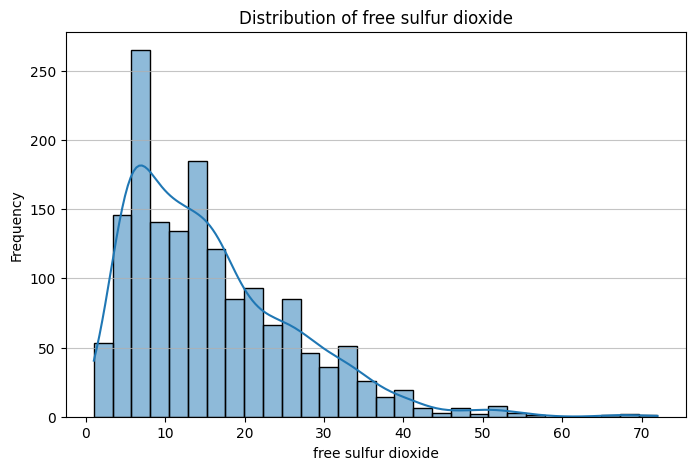

count    1599.000000
mean       46.467792
std        32.895324
min         6.000000
25%        22.000000
50%        38.000000
75%        62.000000
max       289.000000
Name: total sulfur dioxide, dtype: float64


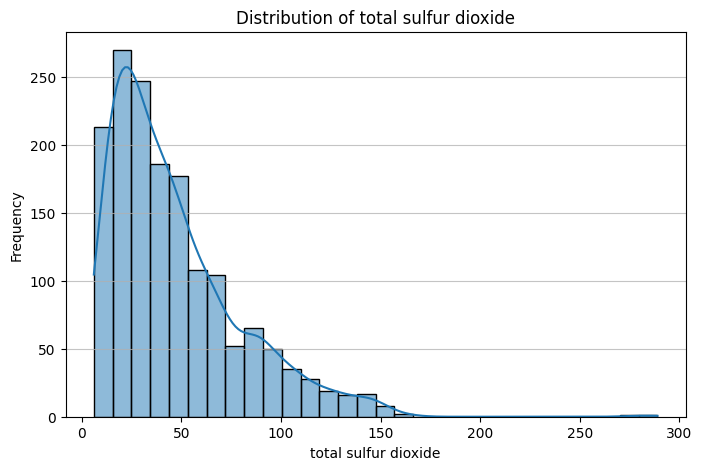

count    1599.000000
mean        0.996747
std         0.001887
min         0.990070
25%         0.995600
50%         0.996750
75%         0.997835
max         1.003690
Name: density, dtype: float64


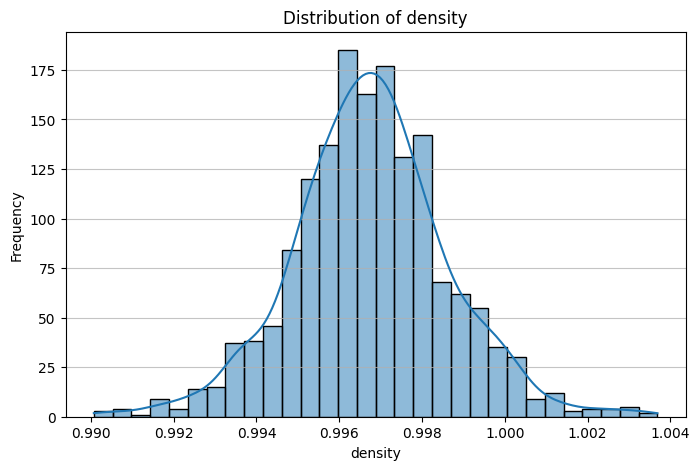

count    1599.000000
mean        3.311113
std         0.154386
min         2.740000
25%         3.210000
50%         3.310000
75%         3.400000
max         4.010000
Name: pH, dtype: float64


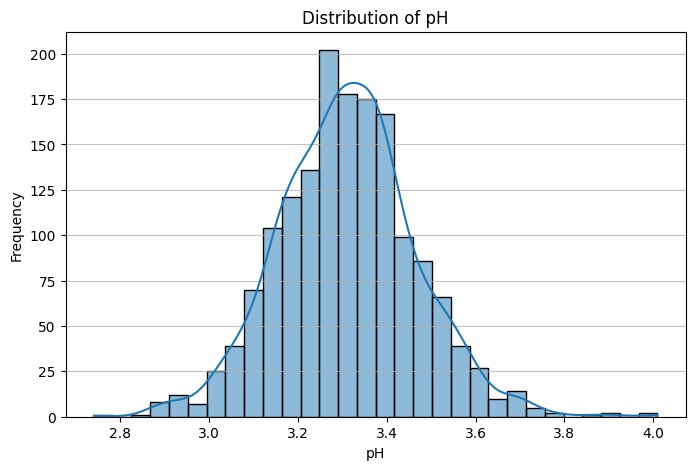

count    1599.000000
mean        0.658149
std         0.169507
min         0.330000
25%         0.550000
50%         0.620000
75%         0.730000
max         2.000000
Name: sulphates, dtype: float64


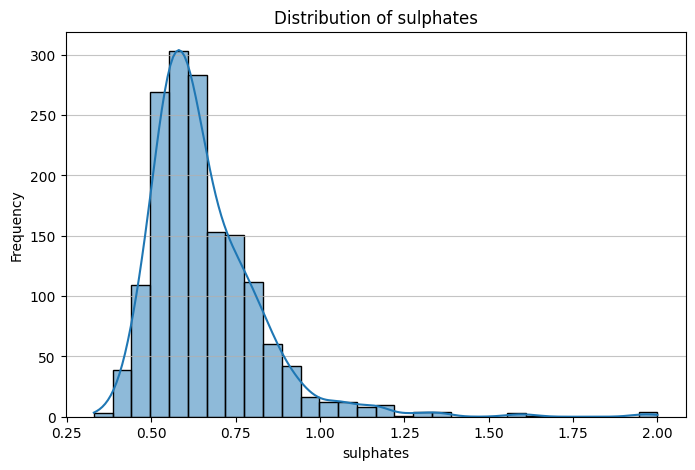

count    1599.000000
mean       10.422983
std         1.065668
min         8.400000
25%         9.500000
50%        10.200000
75%        11.100000
max        14.900000
Name: alcohol, dtype: float64


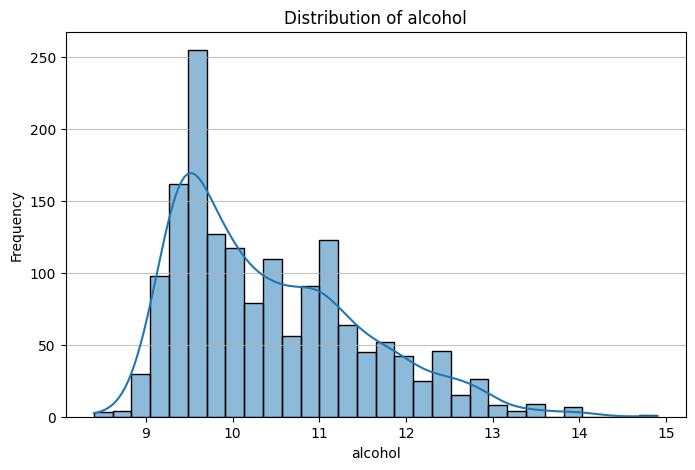

In [ ]:
for col in numerical_cols:
    print(df[col].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

## Univariate analysis
##### Fixed acidity: peaks around 7
##### Volatile acidity: bimodal distribution, peak around 0.6 and 0.4
##### Citric acid: spread out, has a lot of values close to zero
##### Residual sugar: peak at 2
##### Chlorides: peak at around 0.075
##### free sulfur dioxide: average around 15
##### total sulfur dioxide: has a lot of values close to zero
##### density: normal distribution, average at 0.99
##### pH: normal distribution, average at 3.3
##### sulphates: average around 0.6
##### alcohol: peak between 9 and 10, average 10

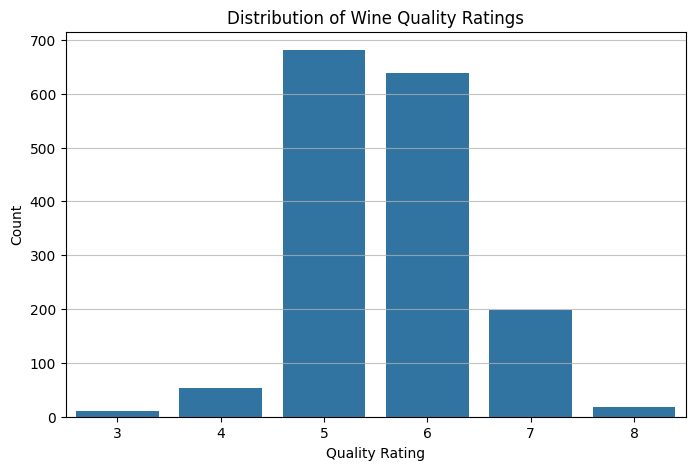

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

A very high number of wines are rated 5 and 6. Might lead to imbalance.

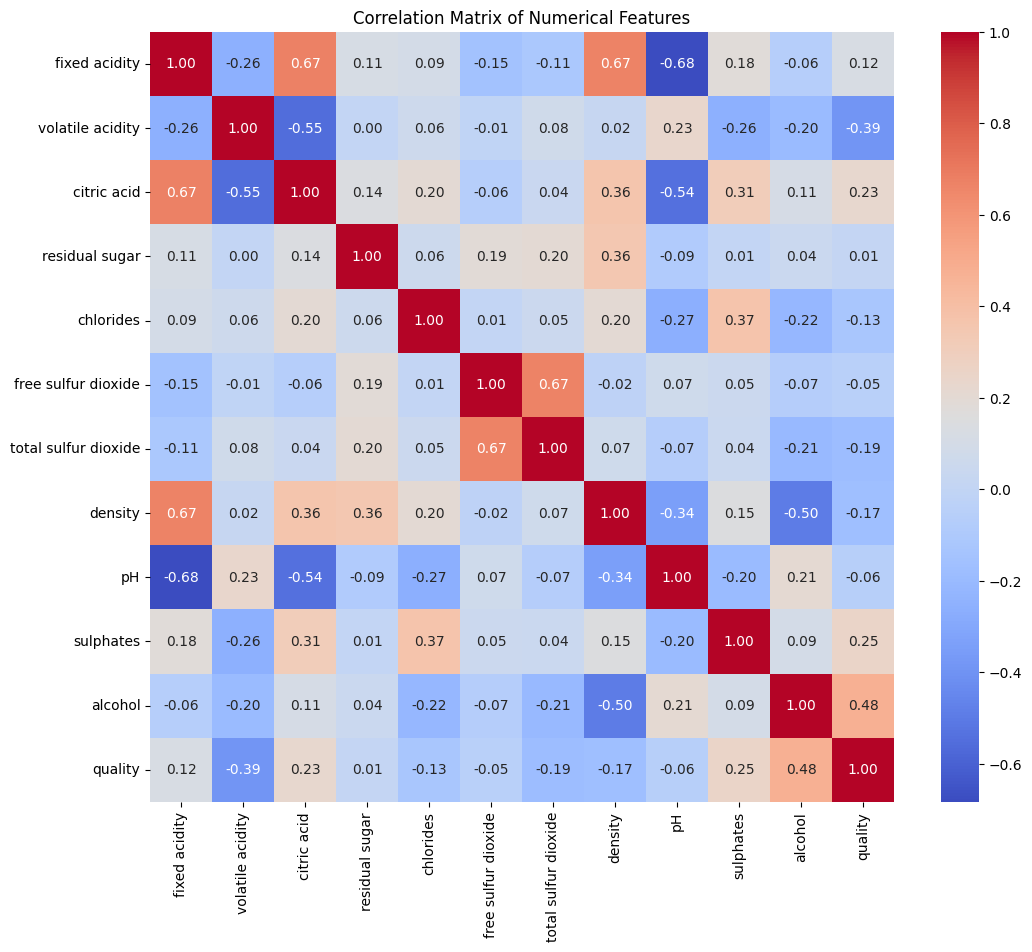

In [ ]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

Residual sugar, free sulfur dioxide, pH have low correlation

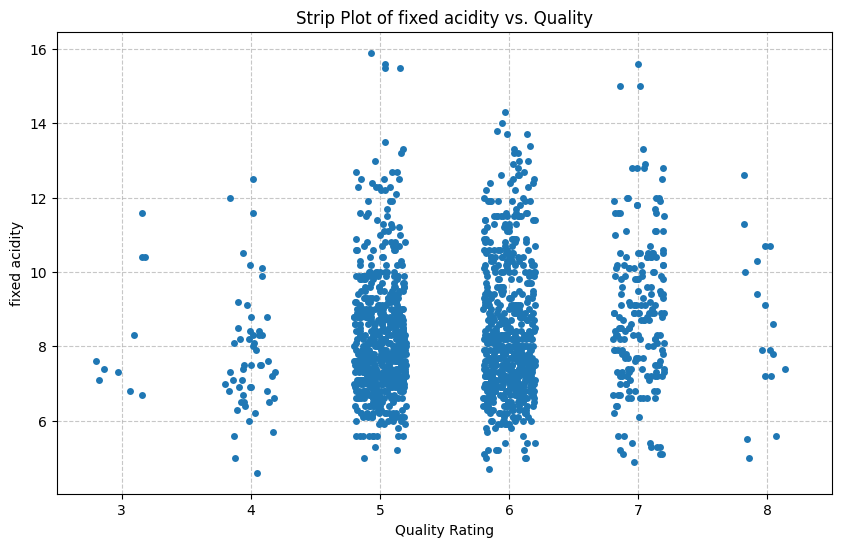

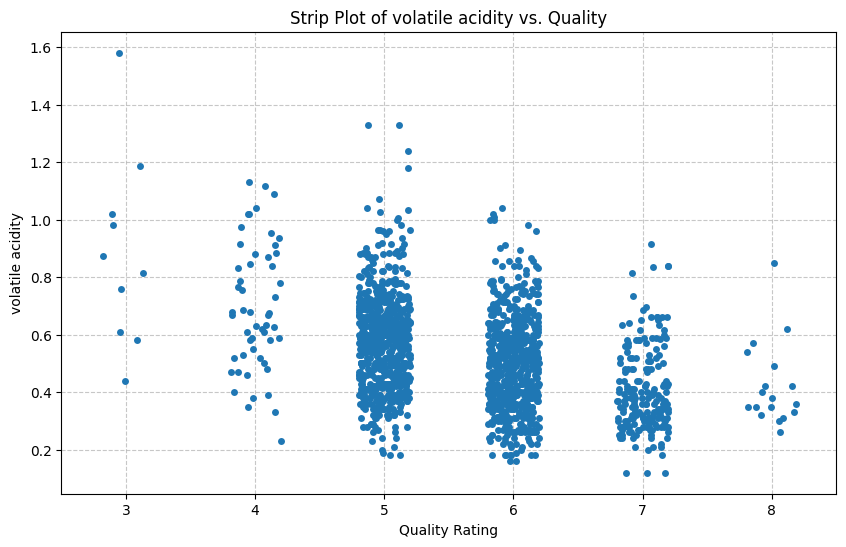

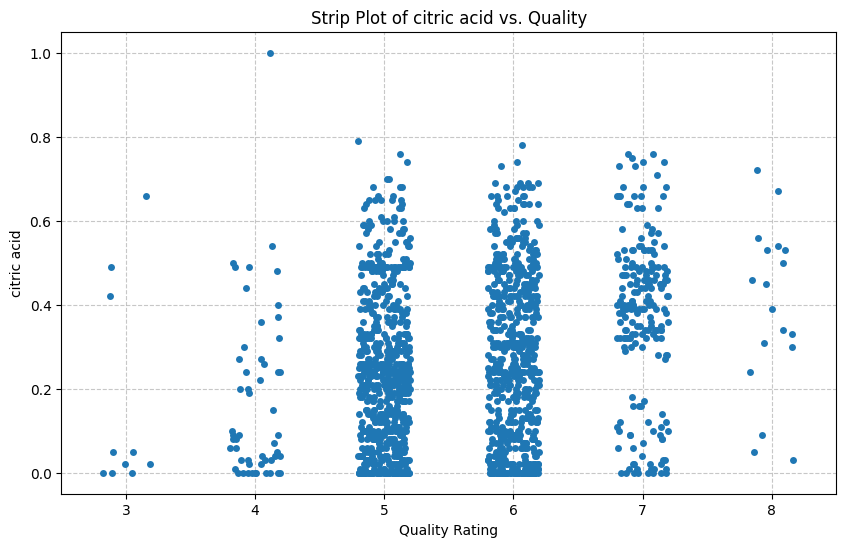

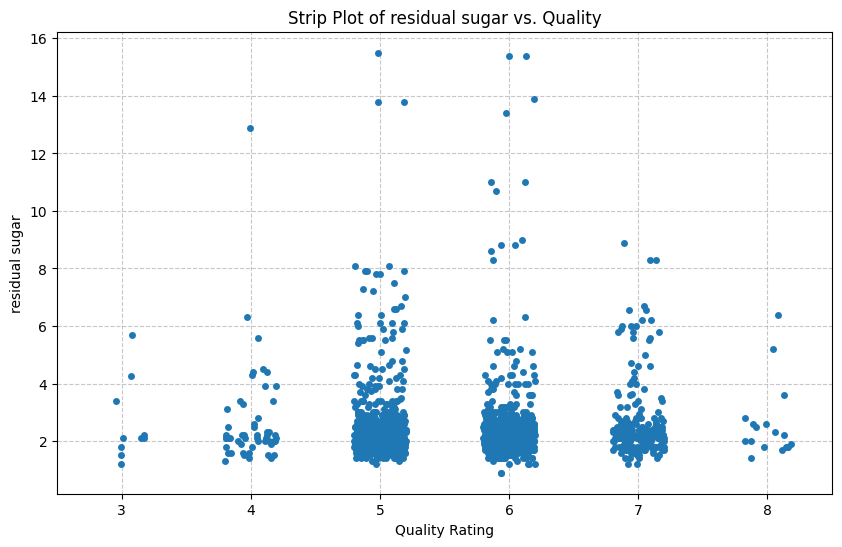

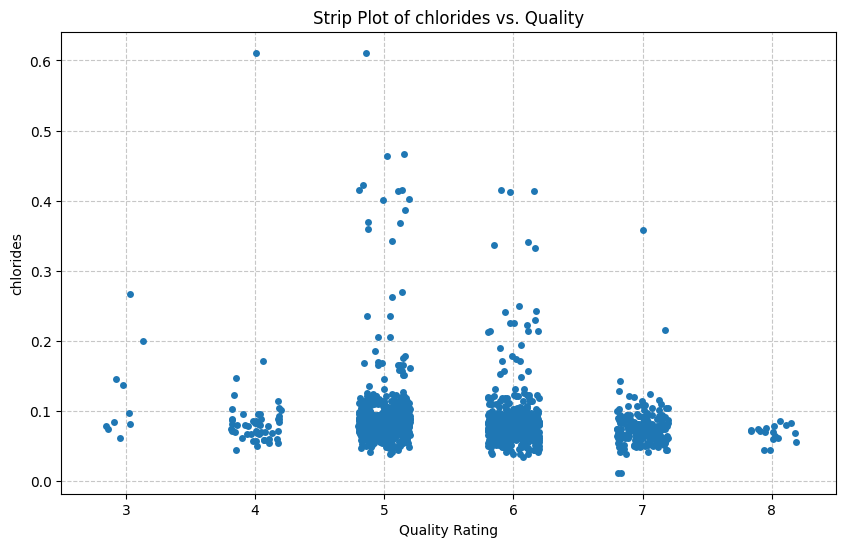

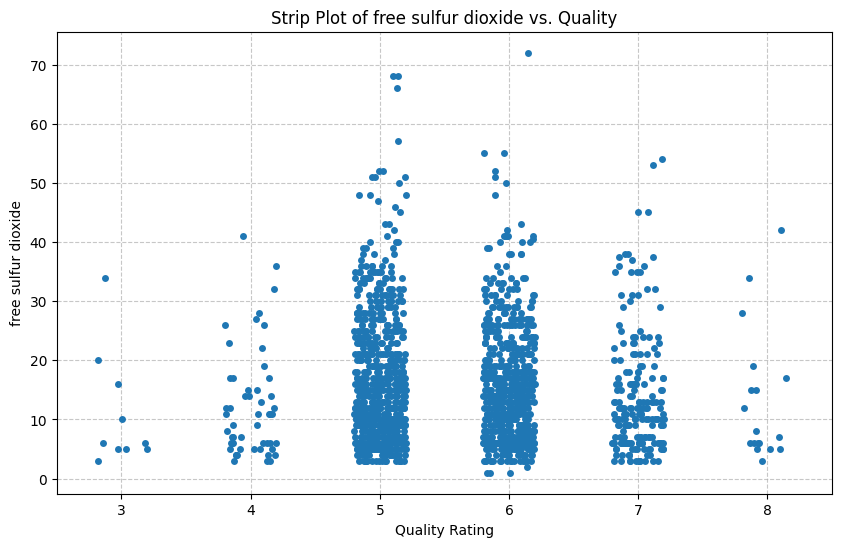

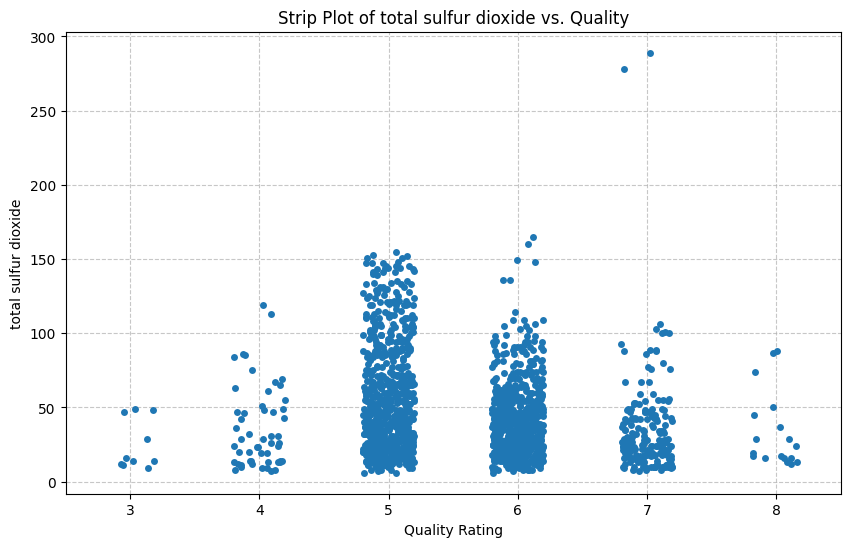

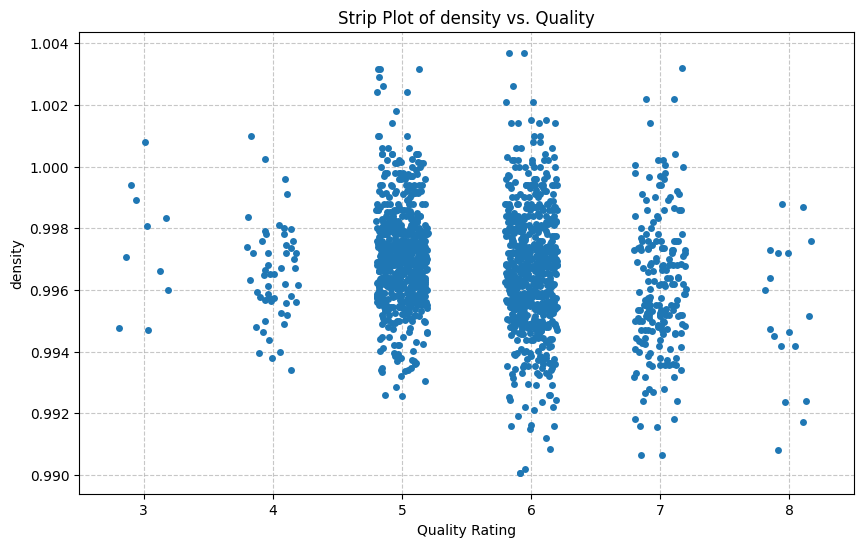

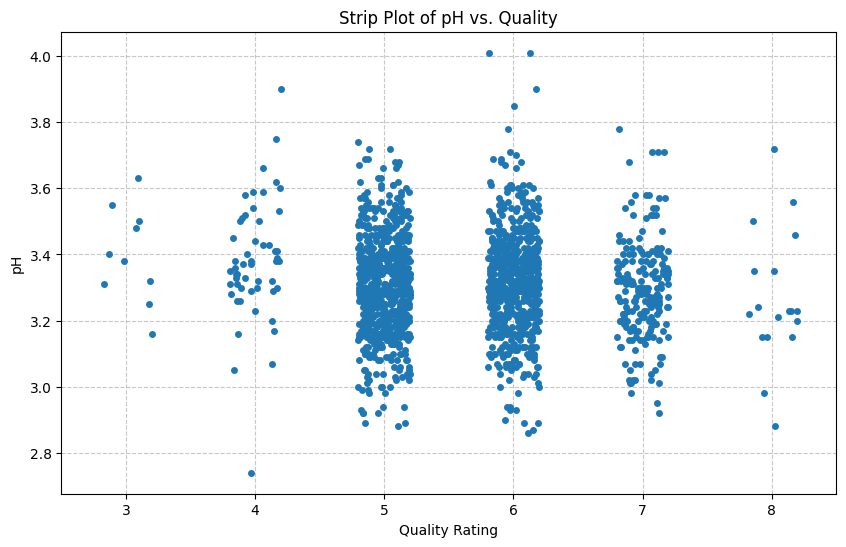

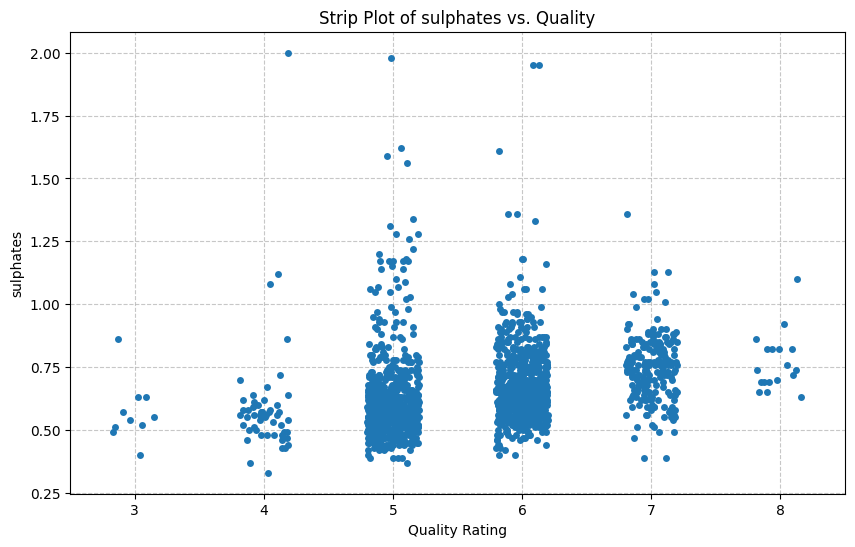

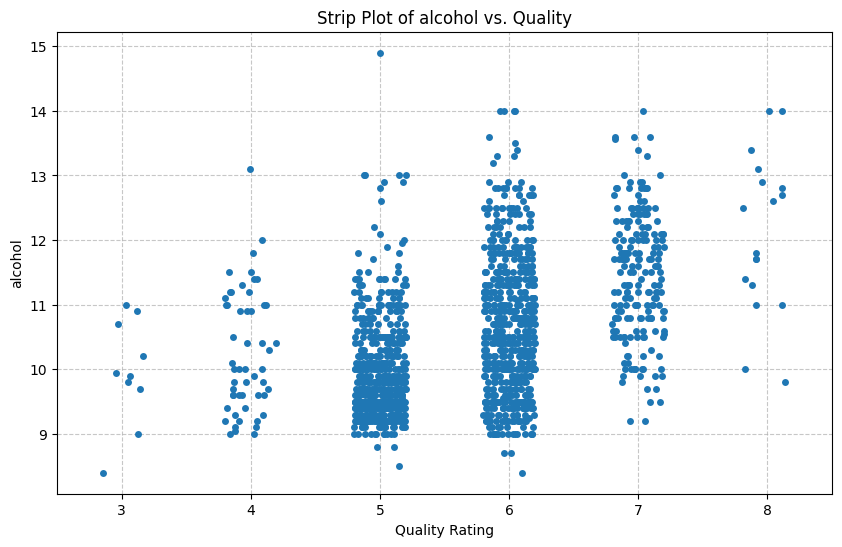

In [ ]:
# Strip plot; Bivariate analysis
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'quality' in numerical_cols:
    numerical_cols.remove('quality')

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.stripplot(x='quality', y=col, data=df, jitter=0.2)
    plt.title(f'Strip Plot of {col} vs. Quality')
    plt.xlabel('Quality Rating')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

## Model

In [ ]:
#binary label
df['quality_bin'] = (df['quality'] >= 6).astype(int)
X = df.drop(['quality','quality_bin'], axis=1)
Y = df['quality_bin']

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
# Normalization
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [ ]:
# Hyperparameters
parameters = {'C':[0.1,1,10], 'gamma':['scale',0.01,0.1], 'kernel':['rbf']}

In [ ]:
# Split into 4 folds for cross validation
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

In [ ]:
# GridSearch
grid = GridSearchCV(SVC(probability=True, random_state=42), parameters, cv=cv, scoring='f1', n_jobs=-1)

In [ ]:
# Train
grid.fit(x_train, y_train)
best = grid.best_estimator_
# Best parameters
print("best params", grid.best_params_)

best params {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


In [ ]:
# Prediction for the base model before adding noise
y_pred = best.predict(x_test)
y_proba = best.predict_proba(x_test)[:,1]
baseline_f1 = f1_score(y_test, y_pred)
print("Baseline F1:", baseline_f1)

Baseline F1: 0.7692307692307693


## Noise

In [ ]:
# Standard deviation values for noise
noise_levels = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0 ]

In [ ]:
rng = np.random.RandomState(42)

In [ ]:
# List to store performance
records = []

In [ ]:
for noise in noise_levels:
  x_train_noise = x_train + rng.normal(loc=0, scale=noise, size=x_train.shape)
  x_test_noise = x_test + rng.normal(loc=0, scale=noise, size=x_test.shape)
  clfA = SVC(**grid.best_params_, probability=True, random_state=42)
  clfA.fit(x_train_noise, y_train)
  yA = clfA.predict(x_test_noise)
  f1A = f1_score(y_test, yA)
  records.append((noise, f1A))

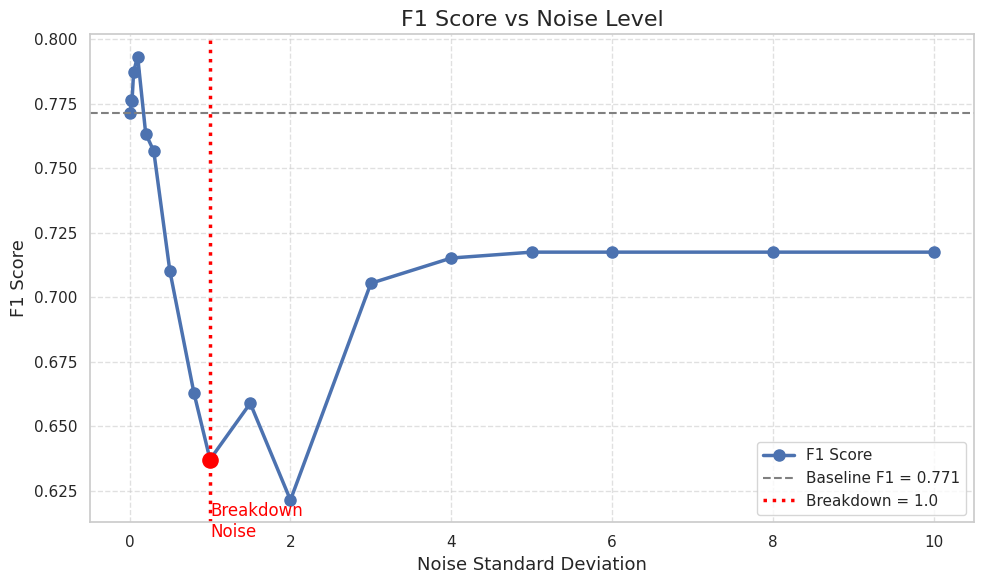

In [ ]:
df_plot = pd.DataFrame(records, columns=["Noise", "F1"])
# Detect breakdown point
baseline_f1 = df_plot["F1"].iloc[0]
threshold_drop = 0.15
df_plot["drop_pct"] = (baseline_f1 - df_plot["F1"]) / baseline_f1
breakdown_row = df_plot[df_plot["drop_pct"] >= threshold_drop].head(1)
if not breakdown_row.empty:
    breakdown_noise = breakdown_row["Noise"].values[0]
    breakdown_f1 = breakdown_row["F1"].values[0]
else:
    breakdown_noise = None

plt.figure(figsize=(10, 6))
plt.plot(df_plot["Noise"],df_plot["F1"], marker="o", linestyle="-", linewidth=2.5, markersize=8, label="F1 Score")
plt.axhline(baseline_f1, color="gray", linestyle="--", linewidth=1.5, label=f"Baseline F1 = {baseline_f1:.3f}")
if breakdown_noise is not None:
    plt.axvline(
        breakdown_noise,
        color="red",
        linestyle=":",
        linewidth=2.5,
        label=f"Breakdown = {breakdown_noise}"
    )

    plt.scatter(
        breakdown_noise,
        breakdown_f1,
        color="red",
        s=120,
        zorder=5
    )

    plt.text(
        breakdown_noise,
        breakdown_f1 - 0.03,
        f"Breakdown\nNoise",
        color="red",
        fontsize=12
    )

plt.title("F1 Score vs Noise Level", fontsize=16)
plt.xlabel("Noise Standard Deviation", fontsize=13)
plt.ylabel("F1 Score", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

##### Initially, the f1 score increases slightly, but then we can quickly see it sharply decreasing.
##### I set the breakdown point to be 85% of the baseline.
##### Then after sometime, we can see the f1 score flatlining. This is because the features start getting dominated by the noise, so the model cannot separate the classes. Hence, the model now is as good as any majority class predictor.
##### Retraining on heavily noised data gives similar random-looking decision boundaries each time, so F1 values stabilize.

### The SVM is model remains stable at low noise but begins to degrade as noise increases.